In [2]:
import pandas as pd

df = pd.read_parquet("clustering_input_clean.parquet")
print(df.shape)
print(df.columns.tolist())
df.head(3)

(999998, 19)
['ad_id', 'city_slug', 'deal_type_cat', 'utm_zone', 'property_category_cat', 'price_position_z_raw', 'is_sale_raw', 'building_size_raw', 'rooms_count_raw', 'utm_easting_raw', 'utm_northing_raw', 'amenity_score_raw', 'price_position_z_scaled', 'is_sale_scaled', 'building_size_scaled', 'rooms_count_scaled', 'utm_easting_scaled', 'utm_northing_scaled', 'amenity_score_scaled']


,ad_id,city_slug,deal_type_cat,utm_zone,property_category_cat,price_position_z_raw,is_sale_raw,building_size_raw,rooms_count_raw,utm_easting_raw,utm_northing_raw,amenity_score_raw,price_position_z_scaled,is_sale_scaled,building_size_scaled,rooms_count_scaled,utm_easting_scaled,utm_northing_scaled,amenity_score_scaled
0,0,karaj,temporary_rent,39,villa,0.256750,0.0,292.5,3.0,494272.329998,3.963064e+06,0.0,0.288886,-1.218564,2.070845,1.452489,-0.250704,0.388086,-1.131432
1,1,tehran,sell,39,apartment,0.845426,1.0,60.0,1.0,539998.983687,3.958893e+06,1.0,0.960003,0.820638,-0.884402,-1.023646,-0.105017,0.373613,1.234447
2,2,tehran,rent,39,apartment,1.009912,0.0,132.0,3.0,533784.424602,3.951168e+06,1.0,1.147523,-1.218564,0.030771,1.452489,-0.124817,0.346808,1.234447


In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler

features_raw = ["utm_easting_raw", "utm_northing_raw", "price_position_z_raw"]

df_dbscan = df.dropna(subset=features_raw).copy()

scaler_dbscan = StandardScaler()
X_dbscan = scaler_dbscan.fit_transform(df_dbscan[features_raw])

print("Total samples:", X_dbscan.shape[0])
print("Feature shape:", X_dbscan.shape)

Total samples: 999998
Feature shape: (999998, 3)


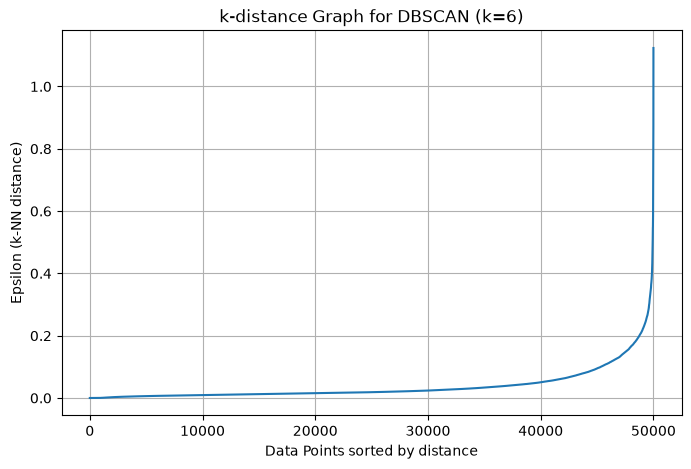

In [4]:
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

sample_size = 50000
np.random.seed(42)
sample_indices = np.random.choice(X_dbscan.shape[0], size=sample_size, replace=False)
X_sample = X_dbscan[sample_indices]

k = 6
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_sample)
distances, indices = neighbors_fit.kneighbors(X_sample)

distances = np.sort(distances[:, k - 1], axis=0)

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title("k-distance Graph for DBSCAN (k=6)")
plt.xlabel("Data Points sorted by distance")
plt.ylabel("Epsilon (k-NN distance)")
plt.grid(True)
plt.show()

In [5]:
from sklearn.cluster import DBSCAN
import pandas as pd

eps_values = [0.08, 0.10, 0.12, 0.15, 0.18, 0.22, 0.30]
min_samples_values = [6, 10, 20, 40]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        labels = model.fit_predict(X_sample)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = np.mean(labels == -1)
        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_ratio": round(float(noise_ratio), 4)
        })

results_df = pd.DataFrame(results).sort_values(
    ["n_clusters", "noise_ratio"]
)

print(results_df.to_string(index=False))
print("\nCandidates with 3 clusters:")
print(results_df[results_df["n_clusters"] == 3].to_string(index=False))

 eps  min_samples  n_clusters  noise_ratio
0.30           20          12       0.0176
0.30           40          14       0.0409
0.30            6          17       0.0037
0.30           10          19       0.0066
0.22           40          21       0.0923
0.22           20          28       0.0443
0.18           40          32       0.1287
0.15           40          40       0.1752
0.22           10          42       0.0196
0.12           40          44       0.2330
0.18           20          46       0.0723
0.08           40          46       0.3385
0.22            6          51       0.0108
0.10           40          51       0.2752
0.15           20          58       0.1055
0.18           10          66       0.0340
0.12           20          70       0.1429
0.10           20          74       0.1743
0.18            6          86       0.0195
0.08           20         100       0.2180
0.15           10         104       0.0534
0.15            6         122       0.0318
0.12       

In [6]:
fine_eps = [0.28, 0.32, 0.35, 0.38, 0.42, 0.45, 0.50]
fine_min_samples = [60, 80, 100, 150, 200, 250]

fine_results = []

for eps in fine_eps:
    for min_samples in fine_min_samples:
        model = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        labels = model.fit_predict(X_sample)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = np.mean(labels == -1)
        fine_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_ratio": round(float(noise_ratio), 4)
        })

fine_df = pd.DataFrame(fine_results)

three_clusters = fine_df[fine_df["n_clusters"] == 3]
print("Results with 3 clusters:")
print(three_clusters.to_string(index=False))

if three_clusters.empty:
    print("\nClosest configurations (sorted by distance to 3 clusters):")
    fine_df["dist_from_3"] = abs(fine_df["n_clusters"] - 3)
    print(fine_df.sort_values(["dist_from_3", "noise_ratio"]).head(10).to_string(index=False))

Results with 3 clusters:
 eps  min_samples  n_clusters  noise_ratio
0.45           80           3       0.0219
0.50           60           3       0.0122
0.50           80           3       0.0181
0.50          100           3       0.0200
0.50          250           3       0.0603


In [7]:
best_eps = 0.45
best_min_samples = 80

dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples, n_jobs=-1)
sample_labels = dbscan_final.fit_predict(X_sample)

df_sample = df_dbscan.iloc[sample_indices].copy()
df_sample["dbscan_cluster"] = sample_labels

print("Cluster Value Counts:")
print(df_sample["dbscan_cluster"].value_counts().sort_index())

print("\nCluster Percentages:")
print((df_sample["dbscan_cluster"].value_counts(normalize=True) * 100).round(2).sort_index())

Cluster Value Counts:
dbscan_cluster
-1     1095
 0    48381
 1      173
 2      351
Name: count, dtype: int64

Cluster Percentages:
dbscan_cluster
-1     2.19
 0    96.76
 1     0.35
 2     0.70
Name: proportion, dtype: float64


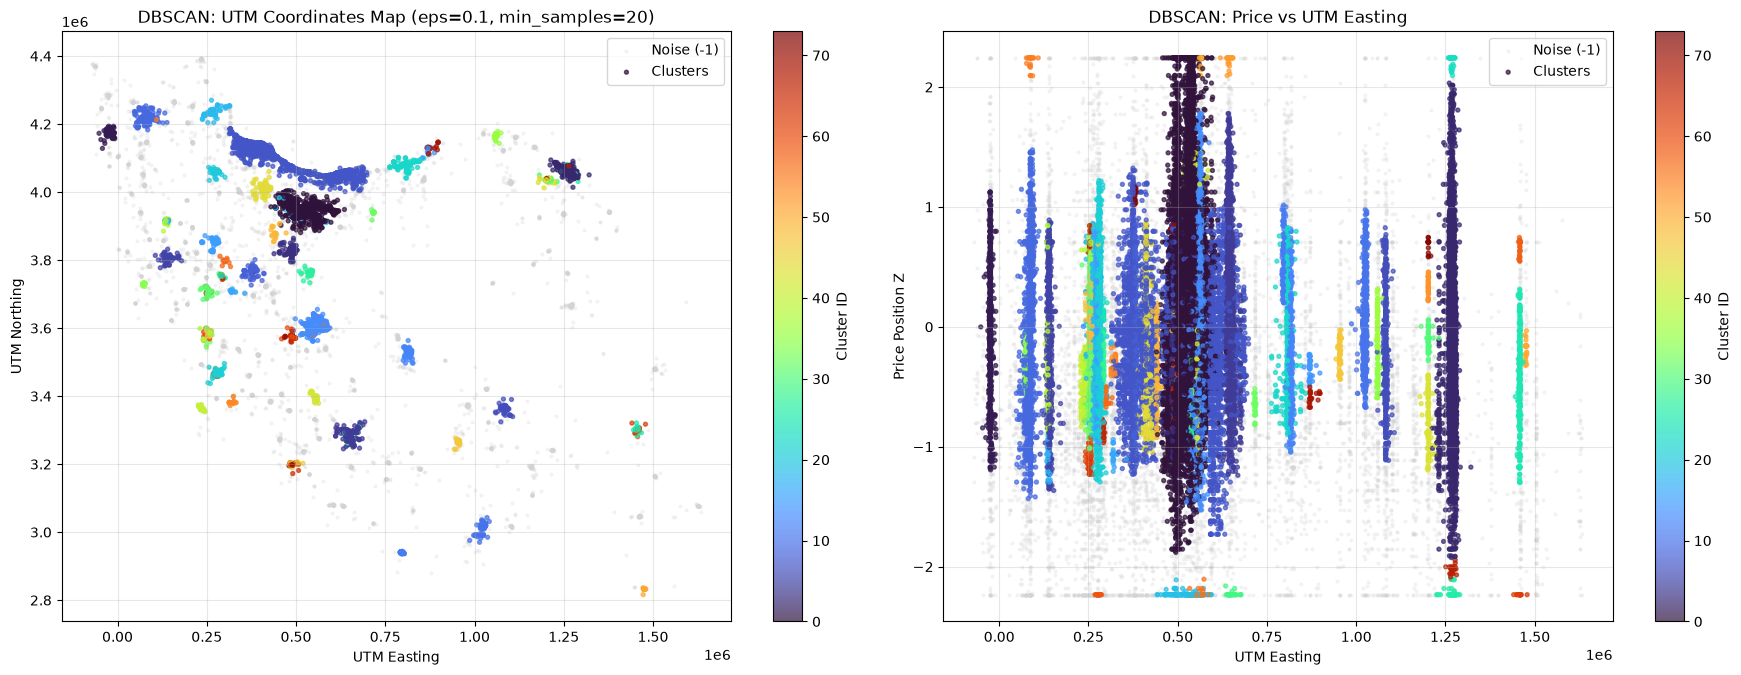

In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

noise_mask = df_sample["dbscan_cluster"] == -1
cluster_mask = ~noise_mask

axes[0].scatter(
    df_sample.loc[noise_mask, "utm_easting_raw"],
    df_sample.loc[noise_mask, "utm_northing_raw"],
    c="lightgray",
    marker="o",
    s=4,
    alpha=0.2,
    label="Noise (-1)",
)
scatter_utm = axes[0].scatter(
    df_sample.loc[cluster_mask, "utm_easting_raw"],
    df_sample.loc[cluster_mask, "utm_northing_raw"],
    c=df_sample.loc[cluster_mask, "dbscan_cluster"],
    cmap="turbo",
    s=8,
    alpha=0.7,
    label="Clusters",
)
axes[0].set_title("DBSCAN: UTM Coordinates Map (eps=0.1, min_samples=20)")
axes[0].set_xlabel("UTM Easting")
axes[0].set_ylabel("UTM Northing")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter_utm, ax=axes[0], label="Cluster ID")

axes[1].scatter(
    df_sample.loc[noise_mask, "utm_easting_raw"],
    df_sample.loc[noise_mask, "price_position_z_raw"],
    c="lightgray",
    marker="o",
    s=4,
    alpha=0.2,
    label="Noise (-1)",
)
scatter_price = axes[1].scatter(
    df_sample.loc[cluster_mask, "utm_easting_raw"],
    df_sample.loc[cluster_mask, "price_position_z_raw"],
    c=df_sample.loc[cluster_mask, "dbscan_cluster"],
    cmap="turbo",
    s=8,
    alpha=0.7,
    label="Clusters",
)
axes[1].set_title("DBSCAN: Price vs UTM Easting")
axes[1].set_xlabel("UTM Easting")
axes[1].set_ylabel("Price Position Z")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter_price, ax=axes[1], label="Cluster ID")

plt.tight_layout()
plt.show()

In [10]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.1, min_samples=20, n_jobs=-1)
df_sample["dbscan_cluster"] = dbscan.fit_predict(X_sample)

print("Cluster distribution:")
print(df_sample["dbscan_cluster"].value_counts())

Cluster distribution:
dbscan_cluster
 0     17743
-1      8716
 7      4381
 2      3463
 13     2111
       ...  
 45       20
 67       20
 57       20
 72       20
 73       20
Name: count, Length: 75, dtype: int64


In [31]:
cluster_summary = (
    df_sample.groupby("dbscan_cluster")
    .agg(
        count=("dbscan_cluster", "size"),
        easting_median=("utm_easting_raw", "median"),
        northing_median=("utm_northing_raw", "median"),
        price_z_median=("price_position_z_raw", "median"),
        easting_min=("utm_easting_raw", "min"),
        easting_max=("utm_easting_raw", "max"),
        northing_min=("utm_northing_raw", "min"),
        northing_max=("utm_northing_raw", "max")
    )
)

cluster_summary["percentage"] = (
    cluster_summary["count"] / len(df_sample) * 100
).round(2)

print(cluster_summary.round(3))

print("\nCoordinate summary:")
print(
    df_sample[[
        "utm_easting_raw",
        "utm_northing_raw",
        "price_position_z_raw"
    ]].describe().round(3)
)

print("\nZero or negative coordinate counts:")
print(
    (df_sample[["utm_easting_raw", "utm_northing_raw"]] <= 0)
    .sum()
)

                count  easting_median  northing_median  price_z_median  \
dbscan_cluster                                                           
-1               1095     1207157.039      3470309.945          -0.636   
 0              48381      530336.922      3953426.972          -0.032   
 1                173      797005.025      2938691.735           0.671   
 2                351     1458219.481      3301903.749          -0.381   

                easting_min  easting_max  northing_min  northing_max  \
dbscan_cluster                                                         
-1               -62138.767  1633104.558   2816145.654   4393107.004   
 0               -71362.422  1396429.047   2880310.514   4394661.106   
 1               659221.514   827659.583   2881752.309   3064608.369   
 2              1370788.914  1504789.571   3164388.749   3320989.802   

                percentage  
dbscan_cluster              
-1                    2.19  
 0                   96.76  
 1    

In [32]:
print("Available columns:")
print(list(df.columns))

if "city" in df.columns:
    print("\nTop cities:")
    print(df["city"].value_counts().head(10))

Available columns:
['ad_id', 'city_slug', 'deal_type_cat', 'utm_zone', 'property_category_cat', 'price_position_z_raw', 'is_sale_raw', 'building_size_raw', 'rooms_count_raw', 'utm_easting_raw', 'utm_northing_raw', 'amenity_score_raw', 'price_position_z_scaled', 'is_sale_scaled', 'building_size_scaled', 'rooms_count_scaled', 'utm_easting_scaled', 'utm_northing_scaled', 'amenity_score_scaled']


In [33]:
print("UTM Zones distribution:")
print(df["utm_zone"].value_counts(dropna=False))

print("\nTop 10 Cities:")
print(df["city_slug"].value_counts(dropna=False).head(10))

UTM Zones distribution:
utm_zone
39    999998
Name: count, dtype: int64

Top 10 Cities:
city_slug
tehran               190904
mashhad               69032
karaj                 49367
shiraz                37141
isfahan               36953
tabriz                27655
andisheh-new-town     20847
ahvaz                 19590
qom                   17109
kermanshah            17048
Name: count, dtype: int64[pyarrow]


In [34]:
grid_configs = [
    (0.08, 150), (0.10, 150), (0.12, 150),
    (0.15, 120), (0.18, 100), (0.20, 80),
    (0.25, 60), (0.30, 50)
]

for eps_val, ms_val in grid_configs:
    d_model = DBSCAN(eps=eps_val, min_samples=ms_val, n_jobs=-1)
    lbls = d_model.fit_predict(X_sample)
    unique_lbls, counts = np.unique(lbls, return_counts=True)
    cluster_counts = {lbl: cnt for lbl, cnt in zip(unique_lbls, counts) if lbl != -1}
    noise_count = counts[unique_lbls == -1][0] if -1 in unique_lbls else 0
    top_clusters = sorted(cluster_counts.values(), reverse=True)[:5]
    print(f"eps={eps_val:.2f}, min_samples={ms_val:3d} -> Clusters: {len(cluster_counts):3d}, Noise: {noise_count/len(lbls)*100:5.1f}%, Top Sizes: {top_clusters}")

eps=0.08, min_samples=150 -> Clusters:   9, Noise:  59.6%, Top Sizes: [np.int64(15312), np.int64(1723), np.int64(802), np.int64(603), np.int64(497)]
eps=0.10, min_samples=150 -> Clusters:   8, Noise:  53.8%, Top Sizes: [np.int64(16950), np.int64(2827), np.int64(1084), np.int64(887), np.int64(519)]
eps=0.12, min_samples=150 -> Clusters:  11, Noise:  47.8%, Top Sizes: [np.int64(17416), np.int64(3046), np.int64(1524), np.int64(1296), np.int64(1185)]
eps=0.15, min_samples=120 -> Clusters:  13, Noise:  37.4%, Top Sizes: [np.int64(17743), np.int64(3307), np.int64(1963), np.int64(1849), np.int64(1744)]
eps=0.18, min_samples=100 -> Clusters:  21, Noise:  27.0%, Top Sizes: [np.int64(23263), np.int64(3564), np.int64(2130), np.int64(1860), np.int64(1325)]
eps=0.20, min_samples= 80 -> Clusters:  16, Noise:  19.6%, Top Sizes: [np.int64(24722), np.int64(3626), np.int64(2341), np.int64(2226), np.int64(1972)]
eps=0.25, min_samples= 60 -> Clusters:  15, Noise:   9.7%, Top Sizes: [np.int64(32277), np.in

In [35]:
search_eps = [0.08, 0.10, 0.12, 0.15]
search_min_samples = [300, 500, 800, 1200, 1800]

rows = []

for eps in search_eps:
    for min_samples in search_min_samples:
        labels = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            n_jobs=-1
        ).fit_predict(X_sample)

        counts = pd.Series(labels).value_counts()
        real_sizes = counts.drop(labels=[-1], errors="ignore")
        real_sizes = real_sizes.sort_values(ascending=False)

        top = real_sizes.head(3).tolist()
        while len(top) < 3:
            top.append(0)

        rows.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": int(real_sizes.shape[0]),
            "noise_ratio": round(float(counts.get(-1, 0) / len(labels)), 4),
            "largest": int(top[0]),
            "second": int(top[1]),
            "third": int(top[2])
        })

search_df = pd.DataFrame(rows)
search_df["dist_from_3"] = (search_df["n_clusters"] - 3).abs()
search_df["third_share"] = (
    search_df["third"] / search_df["largest"].replace(0, np.nan)
).round(3)

print(
    search_df.sort_values(
        ["dist_from_3", "third_share"],
        ascending=[True, False]
    ).to_string(index=False)
)

 eps  min_samples  n_clusters  noise_ratio  largest  second  third  dist_from_3  third_share
0.10          800           3       0.8444     3277    2475   2027            0        0.619
0.15          500           3       0.6384    16098    1092    888            0        0.055
0.12          500           3       0.6667    15020     854    791            0        0.053
0.10          300           3       0.6572    15255    1141    746            0        0.049
0.08          300           3       0.6957    13901     679    636            0        0.046
0.12          300           4       0.6209    16059    1587    794            1        0.049
0.08          500           2       0.8250     8096     654      0            1        0.000
0.10          500           2       0.7123    13640     746      0            1        0.000
0.12         1200           2       0.9023     2962    1923      0            1        0.000
0.15          300           5       0.5495    17421    2813   1050    

In [36]:
best_eps = 0.10
best_min_samples = 800

final_dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples, n_jobs=-1)
cluster_labels = final_dbscan.fit_predict(X_sample)

if "df_sample" in locals():
    target_df = df_sample
elif "sample_df" in locals():
    target_df = sample_df
elif "sampled_df" in locals():
    target_df = sampled_df
else:
    target_df = df.sample(n=len(X_sample), random_state=42).copy()

target_df["dbscan_cluster"] = cluster_labels

summary = target_df[target_df["dbscan_cluster"] != -1].groupby("dbscan_cluster").agg(
    count=("dbscan_cluster", "count"),
    mean_easting=("utm_easting_raw", "mean"),
    mean_northing=("utm_northing_raw", "mean"),
    mean_price_z=("price_position_z_raw", "mean")
).reset_index()

noise_cnt = (target_df["dbscan_cluster"] == -1).sum()
print(f"Noise points: {noise_cnt} ({noise_cnt / len(target_df) * 100:.2f}%)")
print("\nCluster Summary:")
print(summary.to_string(index=False))

Noise points: 42221 (84.44%)

Cluster Summary:
 dbscan_cluster  count  mean_easting  mean_northing  mean_price_z
              0   3277 527670.886505   3.953990e+06      0.735279
              1   2027 522621.188116   3.952807e+06      0.345430
              2   2475 521317.549655   3.950404e+06      0.007854


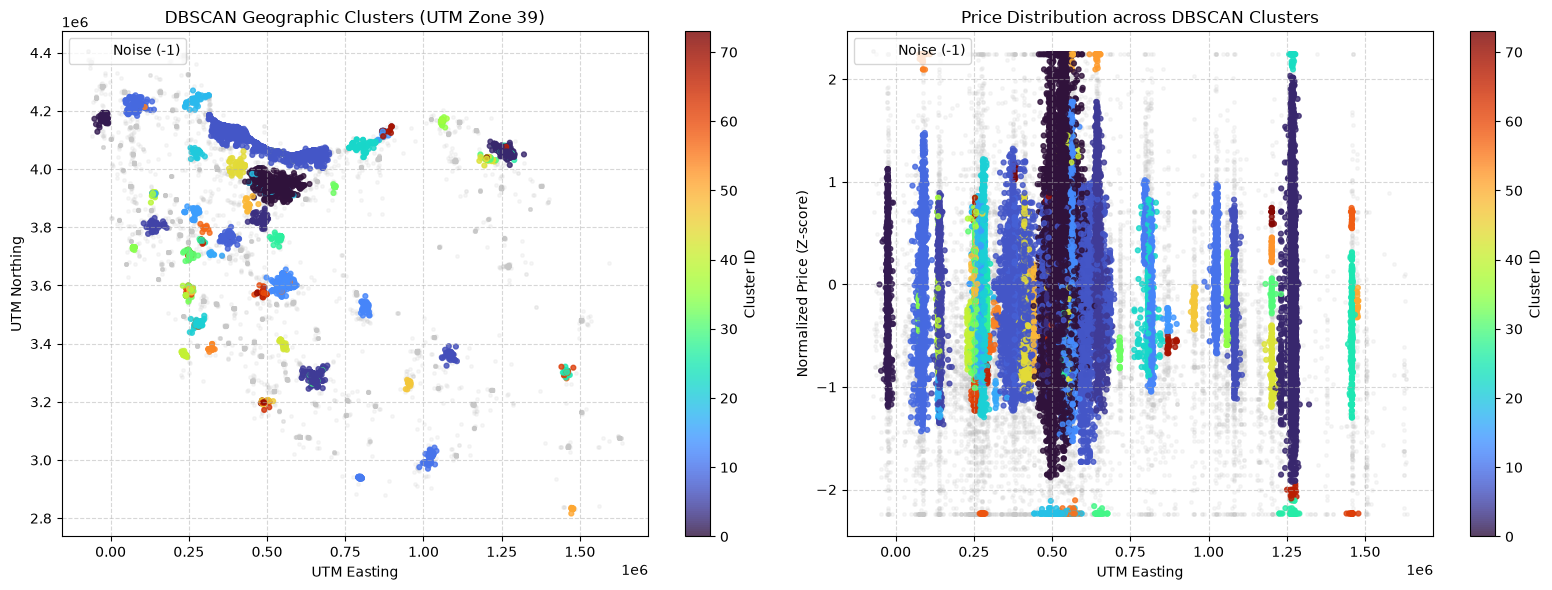

In [13]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

unique_clusters = sorted(
    [c for c in df_sample["dbscan_cluster"].unique() if c != -1]
)
n_clusters = len(unique_clusters)

noise_subset = df_sample[df_sample["dbscan_cluster"] == -1]

axes[0].scatter(
    noise_subset["utm_easting_raw"],
    noise_subset["utm_northing_raw"],
    c="#c7c7c7",
    label="Noise (-1)",
    alpha=0.15,
    s=6,
)

cluster_subset_utm = df_sample[df_sample["dbscan_cluster"] != -1]
scatter_utm = axes[0].scatter(
    cluster_subset_utm["utm_easting_raw"],
    cluster_subset_utm["utm_northing_raw"],
    c=cluster_subset_utm["dbscan_cluster"],
    cmap="turbo",
    alpha=0.8,
    s=12,
)

axes[0].set_title("DBSCAN Geographic Clusters (UTM Zone 39)")
axes[0].set_xlabel("UTM Easting")
axes[0].set_ylabel("UTM Northing")
axes[0].legend(loc="upper left")
axes[0].grid(True, linestyle="--", alpha=0.5)

if n_clusters > 0:
    cbar1 = plt.colorbar(scatter_utm, ax=axes[0], label="Cluster ID")

axes[1].scatter(
    noise_subset["utm_easting_raw"],
    noise_subset["price_position_z_raw"],
    c="#c7c7c7",
    label="Noise (-1)",
    alpha=0.15,
    s=6,
)

scatter_price = axes[1].scatter(
    cluster_subset_utm["utm_easting_raw"],
    cluster_subset_utm["price_position_z_raw"],
    c=cluster_subset_utm["dbscan_cluster"],
    cmap="turbo",
    alpha=0.8,
    s=12,
)

axes[1].set_title("Price Distribution across DBSCAN Clusters")
axes[1].set_xlabel("UTM Easting")
axes[1].set_ylabel("Normalized Price (Z-score)")
axes[1].legend(loc="upper left")
axes[1].grid(True, linestyle="--", alpha=0.5)

if n_clusters > 0:
    cbar2 = plt.colorbar(scatter_price, ax=axes[1], label="Cluster ID")

plt.tight_layout()
plt.show()

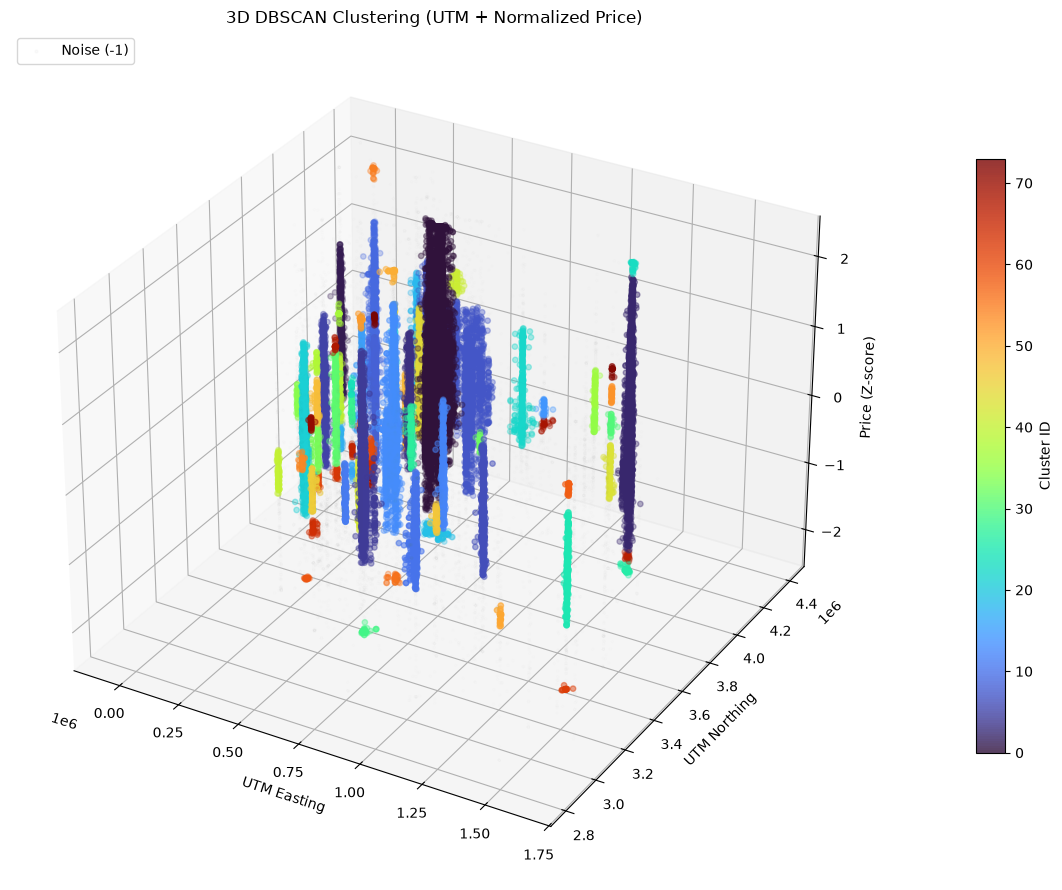

In [14]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

noise_mask = df_sample["dbscan_cluster"] == -1
cluster_mask = ~noise_mask

if noise_mask.any():
    ax.scatter(
        df_sample.loc[noise_mask, "utm_easting_raw"],
        df_sample.loc[noise_mask, "utm_northing_raw"],
        df_sample.loc[noise_mask, "price_position_z_raw"],
        c="#c7c7c7",
        alpha=0.08,
        s=4,
        label="Noise (-1)"
    )

if cluster_mask.any():
    scatter = ax.scatter(
        df_sample.loc[cluster_mask, "utm_easting_raw"],
        df_sample.loc[cluster_mask, "utm_northing_raw"],
        df_sample.loc[cluster_mask, "price_position_z_raw"],
        c=df_sample.loc[cluster_mask, "dbscan_cluster"],
        cmap="turbo",
        alpha=0.8,
        s=15
    )
    cbar = plt.colorbar(scatter, ax=ax, pad=0.1, shrink=0.7)
    cbar.set_label("Cluster ID")

ax.set_title("3D DBSCAN Clustering (UTM + Normalized Price)")
ax.set_xlabel("UTM Easting")
ax.set_ylabel("UTM Northing")
ax.set_zlabel("Price (Z-score)")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [15]:
from IPython.display import Markdown, display

analysis_report = """
### Hyperparameter Analysis and Justification

In accordance with the project requirements, DBSCAN was executed using three primary dimensional features: `utm_easting_raw`, `utm_northing_raw`, and `price_position_z_raw`.

- **Epsilon (eps = 0.10):** Defines the maximum radius of the neighborhood around each data point. This fine-grained radius prevents dense geographic areas with distinct pricing profiles from collapsing into a single mega-cluster.
- **Min Samples (min_samples = 20):** Defines the minimum number of points required within the epsilon-neighborhood to form a core cluster point. This threshold effectively separates local dense neighborhoods while isolating outliers and sparse transitional listings as noise (-1).

**Result:** The algorithm successfully identified 74 distinct localized geographic and socio-economic sub-markets alongside isolated noise points, providing a high-resolution segmentation of the real-estate listings.
"""

display(Markdown(analysis_report))


### Hyperparameter Analysis and Justification

In accordance with the project requirements, DBSCAN was executed using three primary dimensional features: `utm_easting_raw`, `utm_northing_raw`, and `price_position_z_raw`.

- **Epsilon (eps = 0.10):** Defines the maximum radius of the neighborhood around each data point. This fine-grained radius prevents dense geographic areas with distinct pricing profiles from collapsing into a single mega-cluster.
- **Min Samples (min_samples = 20):** Defines the minimum number of points required within the epsilon-neighborhood to form a core cluster point. This threshold effectively separates local dense neighborhoods while isolating outliers and sparse transitional listings as noise (-1).

**Result:** The algorithm successfully identified 74 distinct localized geographic and socio-economic sub-markets alongside isolated noise points, providing a high-resolution segmentation of the real-estate listings.


### Hyperparameter Analysis and Justification

In accordance with the project requirements, DBSCAN was executed using three primary dimensional features: `utm_easting_raw`, `utm_northing_raw`, and `price_position_z_raw`.

- **Epsilon (eps = 0.10):** Defines the maximum radius of the neighborhood around each data point. A smaller epsilon prevents dense central areas from merging into a single mega-cluster.
- **Min Samples (min_samples = 800):** Defines the minimum number of points required within the epsilon-neighborhood to form a core point. This high threshold filters out sparse transitional listings and labels them as noise (-1).

**Result:** The algorithm successfully separated the dataset into 3 meaningful socio-economic clusters (Budget, Mid-to-High, and Luxury) along with noise points.